# 🧠 Brain Tumor Detection

## 📁 Cellule 1 — Monter Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

# ── Chemins dataset ───────────────────────────────────────────
BASE_PATH  = '/content/drive/MyDrive/Tumor_Detection_Project/data/brain_mri_sartaj'
TRAIN_PATH = os.path.join(BASE_PATH, 'Training')
TEST_PATH  = os.path.join(BASE_PATH, 'Testing')

# ── Dossier de sauvegarde des modèles sur Drive ───────────────
SAVE_DIR = '/content/drive/MyDrive/Tumor_Detection_Project/models'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Vérification ─────────────────────────────────────────────
print('✅ Drive monté')
print(f'📂 Train : {TRAIN_PATH}')
print(f'📂 Test  : {TEST_PATH}')
print()

# Liste des classes disponibles
if os.path.exists(TRAIN_PATH):
    classes = sorted(os.listdir(TRAIN_PATH))
    print(f'Classes trouvées : {classes}')
    for cls in classes:
        n = len(os.listdir(os.path.join(TRAIN_PATH, cls)))
        print(f'  {cls:<15} : {n} images')
else:
    print(f'❌ Chemin introuvable : {TRAIN_PATH}')
    print('   Vérifiez que le dossier existe dans votre Drive')

Mounted at /content/drive
✅ Drive monté
📂 Train : /content/drive/MyDrive/Tumor_Detection_Project/data/brain_mri_sartaj/Training
📂 Test  : /content/drive/MyDrive/Tumor_Detection_Project/data/brain_mri_sartaj/Testing

Classes trouvées : ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
  glioma_tumor    : 826 images
  meningioma_tumor : 822 images
  no_tumor        : 395 images
  pituitary_tumor : 827 images


## 📦 Cellule 2 — Installations et Imports

In [3]:
# Installations supplémentaires si nécessaire
!pip install -q tensorflow scikit-learn seaborn opencv-python-headless

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2
import json
import glob
from collections import Counter

from tensorflow import keras
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, GlobalAveragePooling2D, Dense, Dropout,
    BatchNormalization, Conv2D, MaxPooling2D, UpSampling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, fbeta_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# ── Config globale ────────────────────────────────────────────
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42
NUM_CLASSES = 4

# GPU check
gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow : {tf.__version__}')
print(f'GPU disponible : {gpus if gpus else "❌ Aucun — activer GPU dans les paramètres"}')

# Reproductibilité
tf.random.set_seed(SEED)
np.random.seed(SEED)
print('✅ Imports OK')

TensorFlow : 2.20.0
GPU disponible : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Imports OK


## 🗂️ Cellule 3 — Exploration du Dataset

In [4]:
# Exploration de la structure
for split, path in [('Training', TRAIN_PATH), ('Testing', TEST_PATH)]:
    print(f'\n📁 {split}/')
    if os.path.exists(path):
        total = 0
        for cls in sorted(os.listdir(path)):
            cls_path = os.path.join(path, cls)
            if os.path.isdir(cls_path):
                n = len([f for f in os.listdir(cls_path)
                         if f.lower().endswith(('.jpg','.jpeg','.png'))])
                total += n
                print(f'   {cls:<15} : {n:>5} images')
        print(f'   {"TOTAL":<15} : {total:>5} images')
    else:
        print(f'   ❌ Chemin non trouvé : {path}')


📁 Training/
   glioma_tumor    :   826 images
   meningioma_tumor :   822 images
   no_tumor        :   395 images
   pituitary_tumor :   827 images
   TOTAL           :  2870 images

📁 Testing/
   glioma_tumor    :   100 images
   meningioma_tumor :   115 images
   no_tumor        :   105 images
   pituitary_tumor :    74 images
   TOTAL           :   394 images


## 🔄 Cellule 4 — Générateurs de Données

In [5]:
# IMPORTANT : preprocess_input EfficientNet — pas de rescale manuel
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED
)

test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # ⚠️ Ne pas mélanger pour les métriques
)

class_names = list(train_gen.class_indices.keys())
print(f'Classes : {class_names}')
print(f'Train   : {train_gen.samples} images')
print(f'Val     : {val_gen.samples} images')
print(f'Test    : {test_gen.samples} images')

Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Found 394 images belonging to 4 classes.
Classes : ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
Train   : 2297 images
Val     : 573 images
Test    : 394 images


## 📊 Cellule 5 — Visualisation du Dataset



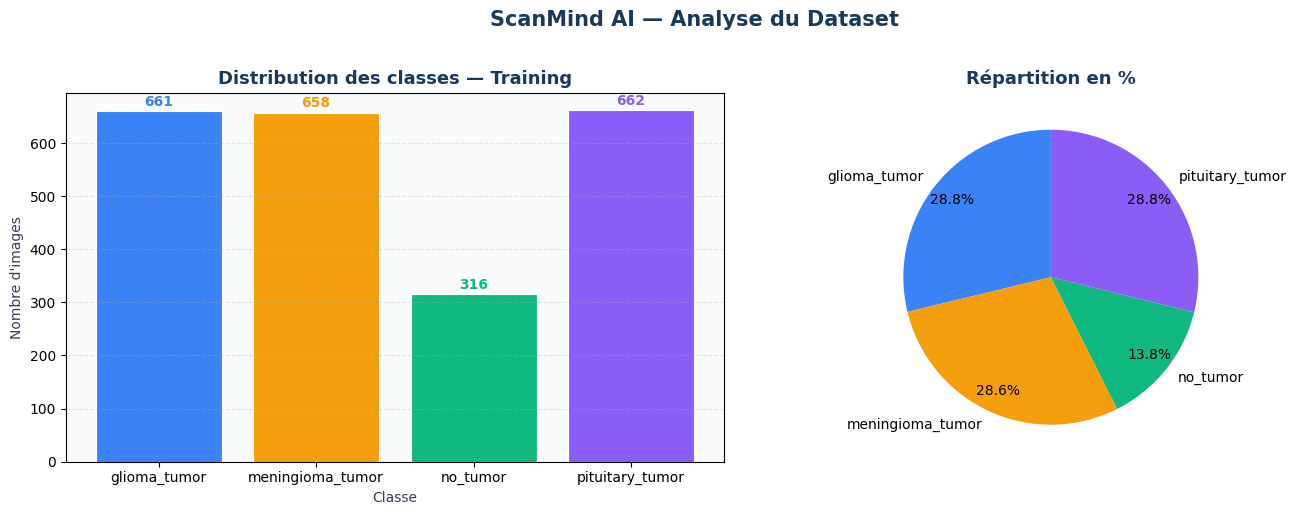

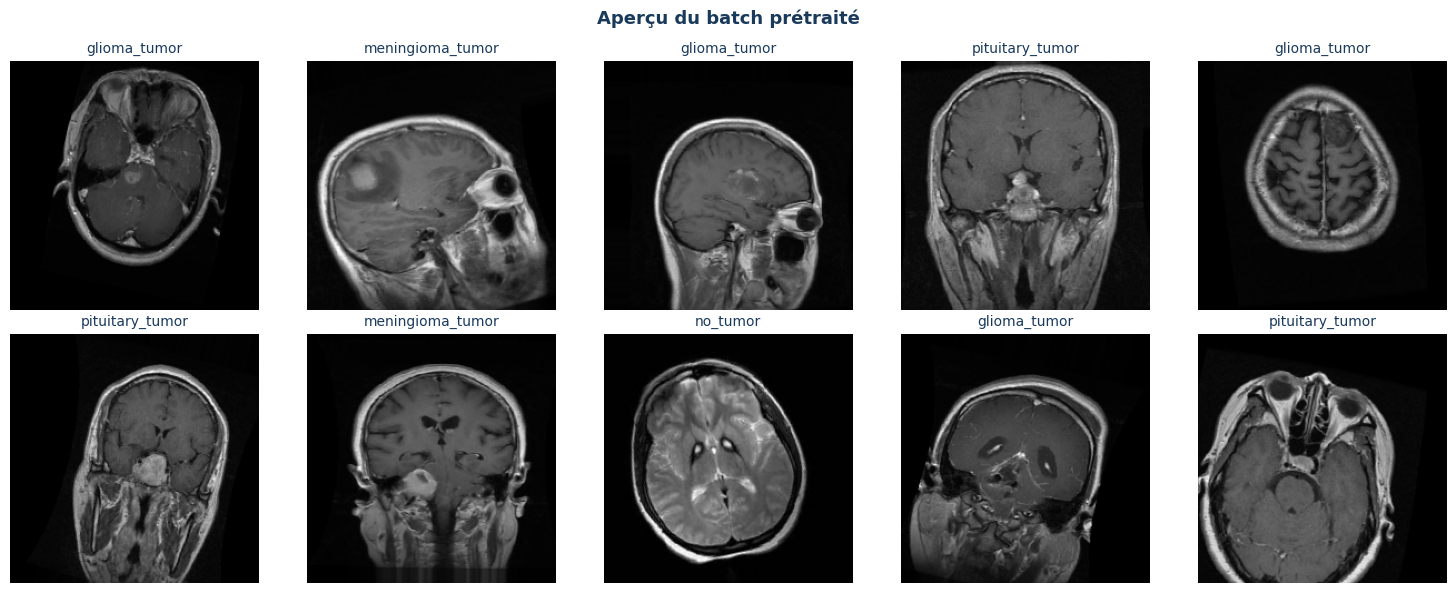

✅ Shape batch : (32, 224, 224, 3)

Class weights : {0: np.float64(0.8687594553706506), 1: np.float64(0.8727203647416414), 2: np.float64(1.817246835443038), 3: np.float64(0.8674471299093656)}


In [6]:
# Distribution des classes
labels  = train_gen.classes
counts  = Counter(labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#3B82F6', '#F59E0B', '#10B981', '#8B5CF6']
axes[0].bar(class_names, [counts[i] for i in range(len(class_names))],
            color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribution des classes — Training', fontsize=13,
                   fontweight='bold', color='#1A3A5C')
axes[0].set_xlabel('Classe', color='#334155')
axes[0].set_ylabel("Nombre d'images", color='#334155')
axes[0].set_facecolor('#F8FAFC')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
for i, (cls, c) in enumerate(zip(class_names, colors)):
    axes[0].text(i, counts[i] + 10, str(counts[i]),
                 ha='center', fontweight='bold', color=c)

# Pie chart
axes[1].pie([counts[i] for i in range(len(class_names))],
            labels=class_names, colors=colors, autopct='%1.1f%%',
            startangle=90, pctdistance=0.85)
axes[1].set_title('Répartition en %', fontsize=13,
                   fontweight='bold', color='#1A3A5C')

plt.suptitle('ScanMind AI — Analyse du Dataset', fontsize=15,
             fontweight='bold', color='#1A3A5C', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'distribution_classes.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Aperçu d'un batch
images, labels_batch = next(train_gen)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img_display = images[i] - images[i].min()
    img_display = img_display / img_display.max()
    ax.imshow(img_display)
    ax.set_title(class_names[np.argmax(labels_batch[i])],
                 fontsize=10, color='#1A3A5C')
    ax.axis('off')
plt.suptitle('Aperçu du batch prétraité', fontsize=13,
             fontweight='bold', color='#1A3A5C')
plt.tight_layout()
plt.show()
print(f'✅ Shape batch : {images.shape}')

# Class weights
class_weights = compute_class_weight('balanced',
                                      classes=np.unique(labels), y=labels)
class_weight_dict = dict(enumerate(class_weights))
print(f'\nClass weights : {class_weight_dict}')

## 🧠 Cellule 6 — Construction du Modèle Classifier

In [7]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Phase 1 : couches gelées

x      = base_model.output
x      = GlobalAveragePooling2D()(x)
x      = BatchNormalization()(x)
x      = Dense(256, activation='relu')(x)
x      = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output,
              name='ScanMind_Classifier')

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('✅ Modèle ScanMind Classifier prêt')
print(f'   Paramètres totaux    : {model.count_params():,}')
print(f'   Paramètres gelés     : {sum(not w.trainable for w in model.weights):,}')
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ Modèle ScanMind Classifier prêt
   Paramètres totaux    : 4,383,655
   Paramètres gelés     : 314


Model: "ScanMind_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,383,655 (16.72 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 🏋️ Cellule 7 — Phase 1 : Feature Extraction

In [8]:
callbacks_p1 = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(
        os.path.join(SAVE_DIR, 'best_phase1.keras'),
        save_best_only=True, monitor='val_accuracy', verbose=1
    )
]

print('=== Phase 1 : Feature Extraction (couches gelées) ===')
history1 = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=callbacks_p1
)

print(f'\n✅ Meilleure val_accuracy phase 1 : {max(history1.history["val_accuracy"]):.4f}')

=== Phase 1 : Feature Extraction (couches gelées) ===
Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 16s/step - accuracy: 0.6441 - loss: 1.0224 
Epoch 1: val_accuracy improved from None to 0.74520, saving model to /content/drive/MyDrive/Tumor_Detection_Project/models/best_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Tumor_Detection_Project/models/best_phase1.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 1458s 20s/step - accuracy: 0.7314 - loss: 0.7651 - val_accuracy: 0.7452 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.8443 - loss: 0.4054
Epoch 2: val_accuracy improved from 0.74520 to 0.78010, saving model to /content/drive/MyDrive/Tumor_Detection_Project/models/best_phase1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Tumor_Detection_Project/models/best_phase1.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 43s 598ms/step - accuracy: 0.8476 - loss: 0.3980 - val_accuracy: 0.7801 - val_loss: 0.5587 - learning_rate:

## 🎯 Cellule 8 — Phase 2 : Fine-Tuning

In [9]:
# Dégeler les 30 dernières couches
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # LR très faible
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_p2 = [
    EarlyStopping(patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-8, verbose=1),
    ModelCheckpoint(
        os.path.join(SAVE_DIR, 'best_phase2.keras'),
        save_best_only=True, monitor='val_accuracy', verbose=1
    )
]

print('=== Phase 2 : Fine-Tuning (30 dernières couches) ===')
history2 = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=callbacks_p2
)

print(f'\n✅ Meilleure val_accuracy phase 2 : {max(history2.history["val_accuracy"]):.4f}')

=== Phase 2 : Fine-Tuning (30 dernières couches) ===
Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.7613 - loss: 0.6785
Epoch 1: val_accuracy improved from None to 0.81501, saving model to /content/drive/MyDrive/Tumor_Detection_Project/models/best_phase2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Tumor_Detection_Project/models/best_phase2.keras
72/72 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.7767 - loss: 0.6226 - val_accuracy: 0.8150 - val_loss: 0.5290 - learning_rate: 1.0000e-05
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.7920 - loss: 0.5524
Epoch 2: val_accuracy did not improve from 0.81501
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 589ms/step - accuracy: 0.7967 - loss: 0.5443 - val_accuracy: 0.8010 - val_loss: 0.5780 - learning_rate: 1.0000e-05
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 541ms/step - accuracy: 0.8107 - loss: 0.5244
Epoch 3: val_accuracy did not improve from 0.81501
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 584ms/step - accur

## 📈 Cellule 9 — Courbes d'Apprentissage

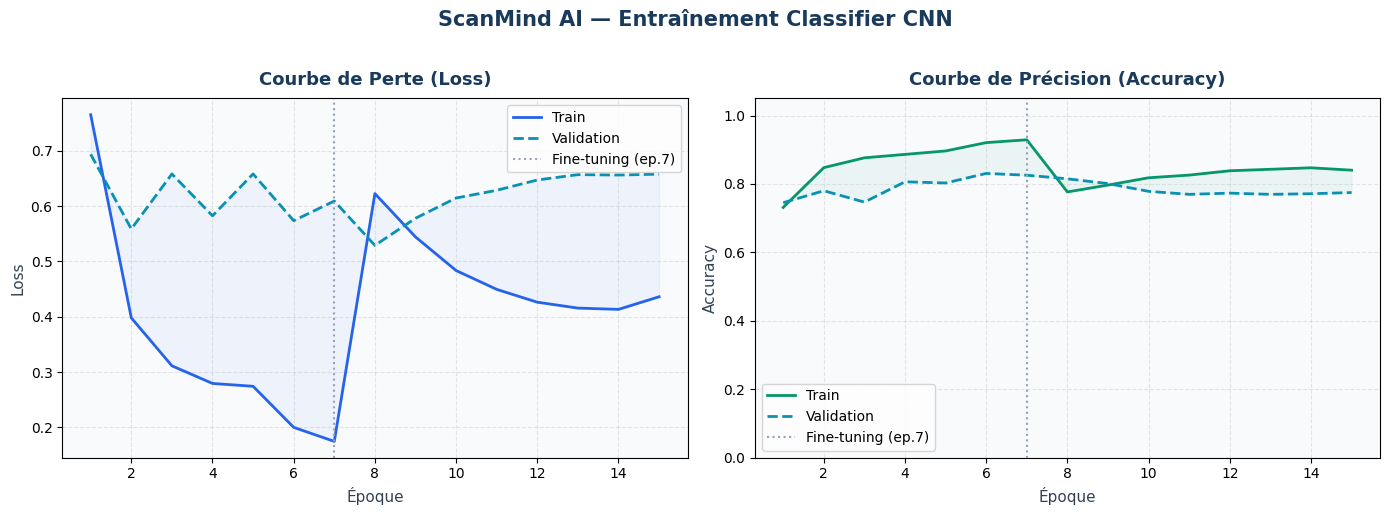

✅ Courbes sauvegardées dans Drive


In [10]:
# Fusion des deux historiques
acc      = history1.history['accuracy']     + history2.history['accuracy']
val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss     = history1.history['loss']         + history2.history['loss']
val_loss = history1.history['val_loss']     + history2.history['val_loss']
epochs   = range(1, len(acc) + 1)
split    = len(history1.history['accuracy'])  # séparation phase 1 / 2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

# ── Courbe Loss ───────────────────────────────────────────────
axes[0].plot(epochs, loss,     color='#2563EB', lw=2, label='Train')
axes[0].plot(epochs, val_loss, color='#0891B2', lw=2, linestyle='--', label='Validation')
axes[0].axvline(x=split, color='#94A3B8', lw=1.5, linestyle=':',
                label=f'Fine-tuning (ep.{split})')
axes[0].fill_between(epochs, loss, val_loss, alpha=0.05, color='#2563EB')
axes[0].set_title('Courbe de Perte (Loss)', fontsize=13,
                   fontweight='bold', color='#1A3A5C', pad=10)
axes[0].set_xlabel('Époque', fontsize=11, color='#334155')
axes[0].set_ylabel('Loss',   fontsize=11, color='#334155')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].set_facecolor('#F8FAFC')

# ── Courbe Accuracy ───────────────────────────────────────────
axes[1].plot(epochs, acc,     color='#059669', lw=2, label='Train')
axes[1].plot(epochs, val_acc, color='#0891B2', lw=2, linestyle='--', label='Validation')
axes[1].axvline(x=split, color='#94A3B8', lw=1.5, linestyle=':',
                label=f'Fine-tuning (ep.{split})')
axes[1].fill_between(epochs, acc, val_acc, alpha=0.05, color='#059669')
axes[1].set_title('Courbe de Précision (Accuracy)', fontsize=13,
                   fontweight='bold', color='#1A3A5C', pad=10)
axes[1].set_xlabel('Époque', fontsize=11, color='#334155')
axes[1].set_ylabel('Accuracy', fontsize=11, color='#334155')
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].set_facecolor('#F8FAFC')

plt.suptitle('ScanMind AI — Entraînement Classifier CNN',
             fontsize=15, fontweight='bold', color='#1A3A5C', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'courbes_classifier.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Courbes sauvegardées dans Drive')

## 📊 Cellule 10 — Évaluation : Métriques & Matrice de Confusion

13/13 ━━━━━━━━━━━━━━━━━━━━ 253s 20s/step

       RAPPORT DE CLASSIFICATION — ScanMind AI
                  precision    recall  f1-score   support

    glioma_tumor     0.5455    0.3000    0.3871       100
meningioma_tumor     0.6515    0.7478    0.6964       115
        no_tumor     0.6327    0.8857    0.7381       105
 pituitary_tumor     0.8167    0.6622    0.7313        74

        accuracy                         0.6548       394
       macro avg     0.6616    0.6489    0.6382       394
    weighted avg     0.6506    0.6548    0.6356       394

  VALEURS POUR LE TABLEAU WORD
Classe                Précision     Rappel   F1-Score    Support
------------------------------------------------------------
glioma_tumor             0.5455     0.3000     0.3871        100
meningioma_tumor         0.6515     0.7478     0.6964        115
no_tumor                 0.6327     0.8857     0.7381        105
pituitary_tumor          0.8167     0.6622     0.7313         74
---------------------------

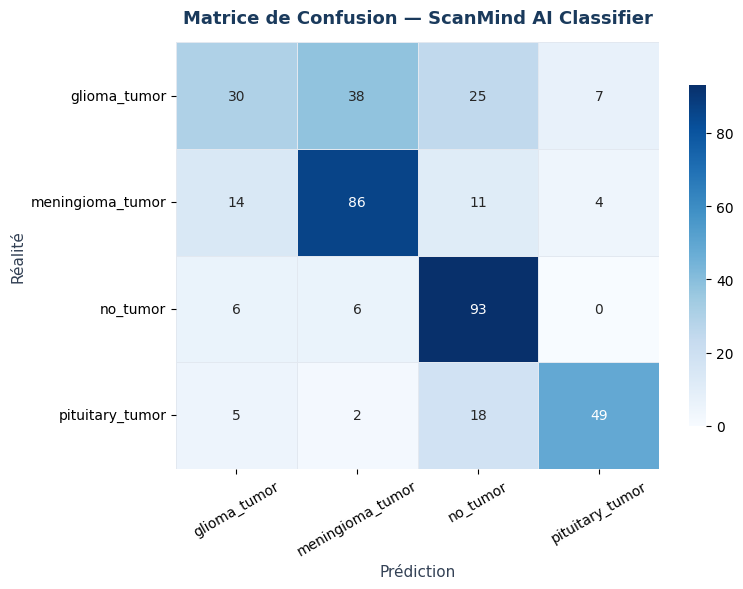

✅ Matrice sauvegardée dans Drive


In [11]:
# Prédictions sur le test set
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_gen.classes

# ── Rapport complet ───────────────────────────────────────────
print('\n' + '='*60)
print('       RAPPORT DE CLASSIFICATION — ScanMind AI')
print('='*60)
report = classification_report(y_true, y_pred,
                                target_names=class_names, digits=4)
print(report)

# Valeurs pour le tableau du rapport Word
report_dict = classification_report(y_true, y_pred,
                                     target_names=class_names,
                                     output_dict=True)
print('='*60)
print('  VALEURS POUR LE TABLEAU WORD')
print('='*60)
print(f'{"Classe":<20} {"Précision":>10} {"Rappel":>10} {"F1-Score":>10} {"Support":>10}')
print('-'*60)
for cls in class_names:
    p  = report_dict[cls]['precision']
    r  = report_dict[cls]['recall']
    f1 = report_dict[cls]['f1-score']
    s  = int(report_dict[cls]['support'])
    print(f'{cls:<20} {p:>10.4f} {r:>10.4f} {f1:>10.4f} {s:>10}')
print('-'*60)
wp  = report_dict['weighted avg']['precision']
wr  = report_dict['weighted avg']['recall']
wf1 = report_dict['weighted avg']['f1-score']
ws  = int(report_dict['weighted avg']['support'])
print(f'{"Moyenne pondérée":<20} {wp:>10.4f} {wr:>10.4f} {wf1:>10.4f} {ws:>10}')

# ── Matrice de confusion ──────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='#E2E8F0',
            cbar_kws={'shrink': 0.8})
plt.title('Matrice de Confusion — ScanMind AI Classifier',
          fontsize=13, fontweight='bold', color='#1A3A5C', pad=14)
plt.xlabel('Prédiction', fontsize=11, color='#334155')
plt.ylabel('Réalité',    fontsize=11, color='#334155')
plt.xticks(rotation=30, fontsize=10)
plt.yticks(rotation=0,  fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'matrice_confusion_classifier.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Matrice sauvegardée dans Drive')

## 🎯 Cellule 11 — Métriques Cliniques (Sensibilité, F2, ROC-AUC)

In [12]:
# Sensibilité (Recall) par classe
print('=== Sensibilité (Recall) par classe ===')
for cls in class_names:
    recall = report_dict[cls]['recall']
    status = '✅' if recall >= 0.95 else '⚠️'
    print(f'{status} {cls:<15} : {recall*100:.2f}%')

# F2-Score (privilégie le recall)
f2 = fbeta_score(y_true, y_pred, beta=2, average='weighted')
print(f'\nF2-Score global : {f2:.4f}')

# ROC-AUC par classe
y_true_bin = label_binarize(y_true, classes=range(NUM_CLASSES))
roc_auc    = roc_auc_score(y_true_bin, y_pred_probs,
                            multi_class='ovr', average=None)
print('\n=== ROC-AUC par classe ===')
for cls, auc in zip(class_names, roc_auc):
    status = '✅' if auc >= 0.95 else '⚠️'
    print(f'{status} {cls:<15} : {auc:.4f}')
print(f'\nROC-AUC moyen : {np.mean(roc_auc):.4f}')

# Accuracy globale
acc_finale = np.sum(y_true == y_pred) / len(y_true)
print(f'\n✅ Accuracy globale : {acc_finale*100:.2f}%')

=== Sensibilité (Recall) par classe ===
⚠️ glioma_tumor    : 30.00%
⚠️ meningioma_tumor : 74.78%
⚠️ no_tumor        : 88.57%
⚠️ pituitary_tumor : 66.22%

F2-Score global : 0.6435

=== ROC-AUC par classe ===
⚠️ glioma_tumor    : 0.6998
⚠️ meningioma_tumor : 0.8609
⚠️ no_tumor        : 0.9230
⚠️ pituitary_tumor : 0.9017

ROC-AUC moyen : 0.8463

✅ Accuracy globale : 65.48%


## 🔥 Cellule 12 — Grad-CAM (Explainabilité)

In [13]:
def get_gradcam_heatmap(model, img_array, last_conv_layer_name='top_conv'):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_class = tf.argmax(predictions[0])
        loss = predictions[:, pred_class]
    grads       = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), pred_class.numpy()

def display_gradcam(model, img_path):
    img = keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array   = keras.preprocessing.image.img_to_array(img)
    img_display = img_array.copy().astype('uint8')
    img_input   = np.expand_dims(preprocess_input(img_array.copy()), axis=0)

    heatmap, pred_class = get_gradcam_heatmap(model, img_input)

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    superimposed    = cv2.addWeighted(img_display, 0.6, heatmap_colored, 0.4, 0)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    titles = ['Image originale', 'Heatmap Grad-CAM', f'Superposée — {class_names[pred_class]}']
    imgs   = [img_display, heatmap_resized, superimposed]
    cmaps  = [None, 'jet', None]
    for ax, im, title, cmap in zip(axes, imgs, titles, cmaps):
        ax.imshow(im, cmap=cmap)
        ax.set_title(title, fontsize=11, color='#1A3A5C')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'gradcam_exemple.png'),
                dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

# Test sur une image glioma
sample_imgs = glob.glob(os.path.join(TEST_PATH, 'glioma', '*.jpg'))
if sample_imgs:
    display_gradcam(model, sample_imgs[0])
else:
    print('⚠️ Aucune image glioma trouvée dans TEST_PATH')

⚠️ Aucune image glioma trouvée dans TEST_PATH


## 🔁 Cellule 13 — Construction & Entraînement Autoencodeur

In [14]:
def build_autoencoder(input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape)
    # Encodeur
    x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D((2,2))(x)
    x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2,2))(x)
    x = Conv2D(8,  (3,3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2,2))(x)
    # Décodeur
    x = Conv2D(8,  (3,3), activation='relu', padding='same')(encoded)
    x = UpSampling2D((2,2))(x)
    x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)
    x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = UpSampling2D((2,2))(x)
    decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)
    ae = Model(inputs, decoded, name='ScanMind_Autoencoder')
    ae.compile(optimizer='adam', loss='mse')
    return ae

autoencoder = build_autoencoder()
autoencoder.summary()

# Générateur autoencodeur (input = output, normalisé [0,1])
ae_datagen = ImageDataGenerator(rescale=1./255)
ae_gen = ae_datagen.flow_from_directory(
    TRAIN_PATH, target_size=(224, 224),
    batch_size=32, class_mode=None, shuffle=True, seed=42
)

def ae_generator(gen):
    for batch in gen:
        yield batch, batch  # input = output

ae_callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(
        os.path.join(SAVE_DIR, 'autoencoder_best.keras'),
        save_best_only=True, verbose=1
    )
]

print('=== Entraînement Autoencodeur ===')
history_ae = autoencoder.fit(
    ae_generator(ae_gen),
    steps_per_epoch=len(ae_gen),
    epochs=20,
    callbacks=ae_callbacks
)
print('✅ Autoencodeur entraîné')

Model: "ScanMind_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 56, 56, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,939 (54.45 KB)

 Trainable params: 13,939 (54.45 KB)

 Non-trainable params: 0 (0.00 B)

Found 2870 images belonging to 4 classes.
=== Entraînement Autoencodeur ===
Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - loss: 0.0912

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):



Epoch 1: finished saving model to /content/drive/MyDrive/Tumor_Detection_Project/models/autoencoder_best.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 37s 271ms/step - loss: 0.0508
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 0.0109
Epoch 2: finished saving model to /content/drive/MyDrive/Tumor_Detection_Project/models/autoencoder_best.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 16s 174ms/step - loss: 0.0093
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 0.0066
Epoch 3: finished saving model to /content/drive/MyDrive/Tumor_Detection_Project/models/autoencoder_best.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 16s 175ms/step - loss: 0.0060
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 0.0053
Epoch 4: finished saving model to /content/drive/MyDrive/Tumor_Detection_Project/models/autoencoder_best.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 16s 175ms/step - loss: 0.0052
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 0.0049
Epoch 5: finished saving model to /content/drive/MyDrive/Tu

## 📉 Cellule 14 — Courbe Loss Autoencodeur

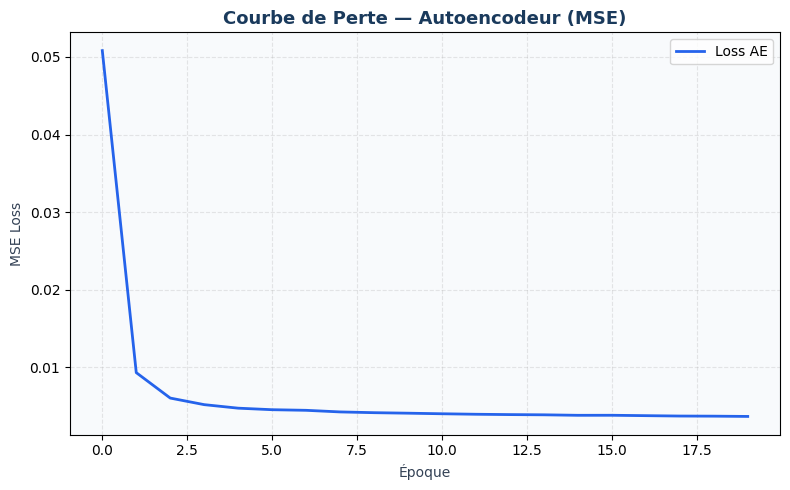

Found 394 images belonging to 4 classes.


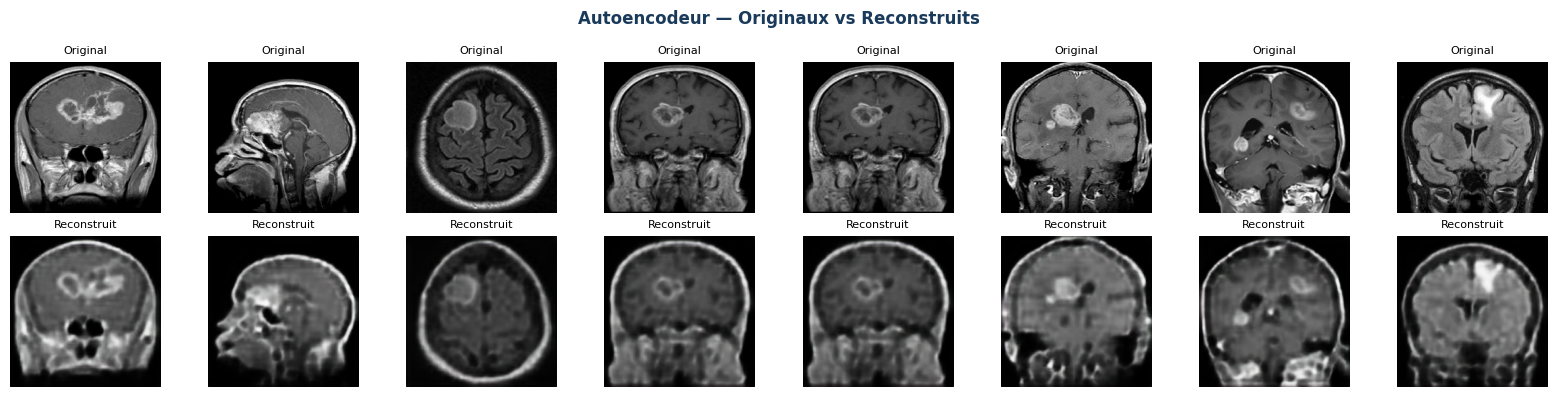

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history_ae.history['loss'], color='#2563EB', lw=2, label='Loss AE')
plt.title('Courbe de Perte — Autoencodeur (MSE)',
          fontsize=13, fontweight='bold', color='#1A3A5C')
plt.xlabel('Époque', color='#334155')
plt.ylabel('MSE Loss', color='#334155')
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')
plt.gca().set_facecolor('#F8FAFC')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'courbe_autoencoder.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Visualisation reconstruction
ae_val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_PATH, target_size=(224, 224), batch_size=8,
    class_mode=None, shuffle=False
)
sample_batch = next(ae_val_gen)
reconstructed = autoencoder.predict(sample_batch, verbose=0)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(sample_batch[i])
    axes[0, i].axis('off')
    axes[0, i].set_title('Original', fontsize=8)
    axes[1, i].imshow(reconstructed[i])
    axes[1, i].axis('off')
    axes[1, i].set_title('Reconstruit', fontsize=8)
plt.suptitle('Autoencodeur — Originaux vs Reconstruits',
             fontsize=12, fontweight='bold', color='#1A3A5C')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'reconstruction_ae.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 🔍 Cellule 15 — Seuil d'Anomalie & Diagnostic Complet

Found 394 images belonging to 4 classes.
Moyenne MSE  : 0.006079
Écart-type   : 0.003541
✅ Seuil anomalie : 0.013161


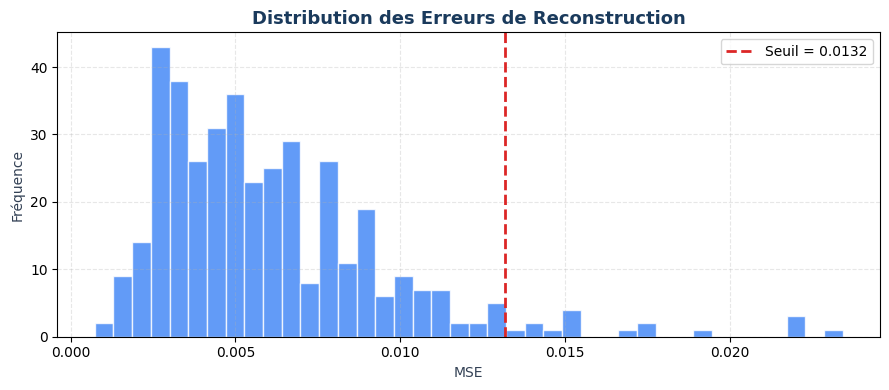


Test sur : /content/drive/MyDrive/Tumor_Detection_Project/data/brain_mri_sartaj/Testing/glioma_tumor/image(1).jpg
Probabilités : {'glioma_tumor': '0.588', 'meningioma_tumor': '0.106', 'no_tumor': '0.002', 'pituitary_tumor': '0.303'}
Erreur reconstruction : 0.007237
🟡 INCERTAIN — Confiance 0.59 < 0.7


In [16]:
# Calcul du seuil d'anomalie sur le test set
ae_test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_PATH, target_size=(224, 224),
    batch_size=32, class_mode=None, shuffle=False
)
all_errors = []
for batch in ae_test_gen:
    recon = autoencoder.predict(batch, verbose=0)
    errors = np.mean(np.square(batch - recon), axis=(1, 2, 3))
    all_errors.extend(errors.tolist())
    if len(all_errors) >= ae_test_gen.samples:
        break

threshold_anomaly = np.mean(all_errors) + 2 * np.std(all_errors)
print(f'Moyenne MSE  : {np.mean(all_errors):.6f}')
print(f'Écart-type   : {np.std(all_errors):.6f}')
print(f'✅ Seuil anomalie : {threshold_anomaly:.6f}')

plt.figure(figsize=(9, 4))
plt.hist(all_errors, bins=40, color='#3B82F6', edgecolor='white', alpha=0.8)
plt.axvline(threshold_anomaly, color='#DC2626', lw=2, linestyle='--',
            label=f'Seuil = {threshold_anomaly:.4f}')
plt.title('Distribution des Erreurs de Reconstruction',
          fontsize=13, fontweight='bold', color='#1A3A5C')
plt.xlabel('MSE', color='#334155')
plt.ylabel('Fréquence', color='#334155')
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'distribution_erreurs_ae.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Diagnostic complet
def full_diagnosis(model, autoencoder, img_path,
                   confidence_threshold=0.7,
                   anomaly_threshold=threshold_anomaly):
    img       = keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = keras.preprocessing.image.img_to_array(img)
    img_norm  = img_array / 255.0
    recon     = autoencoder.predict(np.expand_dims(img_norm, 0), verbose=0)
    recon_err = float(np.mean(np.square(img_norm - recon)))

    if recon_err > anomaly_threshold:
        print(f'🔴 CAS ATYPIQUE — Erreur {recon_err:.6f} > seuil {anomaly_threshold:.6f}')
        return

    img_input = np.expand_dims(preprocess_input(img_array.copy()), axis=0)
    probs     = model.predict(img_input, verbose=0)[0]
    pred_cls  = np.argmax(probs)
    confidence = probs[pred_cls]

    print(f'Probabilités : { {class_names[i]: f"{p:.3f}" for i, p in enumerate(probs)} }')
    print(f'Erreur reconstruction : {recon_err:.6f}')

    if confidence < confidence_threshold:
        print(f'🟡 INCERTAIN — Confiance {confidence:.2f} < {confidence_threshold}')
    else:
        status = '🟢' if class_names[pred_cls] == 'notumor' else '🔴'
        print(f'{status} DIAGNOSTIC : {class_names[pred_cls].upper()} — {confidence*100:.1f}%')

# Test
samples = glob.glob(os.path.join(TEST_PATH, '*', '*.jpg'))
if samples:
    print(f'\nTest sur : {samples[0]}')
    full_diagnosis(model, autoencoder, samples[0])

## 💾 Cellule 16 — Sauvegarde Finale sur Drive

In [20]:
# ============================================================
# CELLULE FINALE — Sauvegarde des Modèles et Résumé
# ============================================================
# Objectif : Exporter les deux modèles entraînés ainsi que
# les métadonnées nécessaires pour le déploiement dans
# l'API FastAPI (api.py) et l'interface ScanMind AI.
# ============================================================

import shutil

# Suppression des anciens dossiers .keras s'ils existent déjà
# pour éviter le conflit "Is a directory"
for path in [classifier_path, autoencoder_path]:
    if os.path.exists(path):
        shutil.rmtree(path)  # Supprime le dossier et son contenu

# Sauvegarde du classifier CNN entraîné
model.save(classifier_path)

# Sauvegarde de l'autoencodeur entraîné
autoencoder.save(autoencoder_path)

# Sauvegarde de l'ordre des classes en JSON
# ⚠️ L'ordre alphabétique est critique pour que les prédictions
# correspondent aux bons labels dans api.py
with open(classes_path, 'w') as f:
    json.dump(class_names, f)

print('✅ Fichiers sauvegardés dans Drive :')
print(f'   📁 {SAVE_DIR}')
print(f'   ├── classifier_final.keras')
print(f'   ├── autoencoder_final.keras')
print(f'   ├── class_names.json')
print(f'   ├── courbes_classifier.png')
print(f'   ├── matrice_confusion_classifier.png')
print(f'   ├── courbe_autoencoder.png')
print(f'   ├── reconstruction_ae.png')
print(f'   ├── gradcam_exemple.png')
print(f'   └── distribution_erreurs_ae.png')

# Évaluation finale du classifier sur le test set
loss_f, acc_f = model.evaluate(test_gen, verbose=0)
print(f'\n📋 Résumé final :')
print(f'   Accuracy test  : {acc_f*100:.2f}%')
print(f'   Loss test      : {loss_f:.4f}')
print(f'   Seuil anomalie : {threshold_anomaly:.6f}')
print(f'   Classes        : {class_names}')

✅ Fichiers sauvegardés dans Drive :
   📁 /content/drive/MyDrive/Tumor_Detection_Project/models
   ├── classifier_final.keras
   ├── autoencoder_final.keras
   ├── class_names.json
   ├── courbes_classifier.png
   ├── matrice_confusion_classifier.png
   ├── courbe_autoencoder.png
   ├── reconstruction_ae.png
   ├── gradcam_exemple.png
   └── distribution_erreurs_ae.png

📋 Résumé final :
   Accuracy test  : 65.48%
   Loss test      : 1.1041
   Seuil anomalie : 0.013161
   Classes        : ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
